# Employee Turnover Analytics — Portobello Tech
### Applied Data Science with Python — Course-End Project 1

**Objective:** Build ML models to predict employee turnover for the HR Department, identify the key drivers of attrition, and recommend targeted retention strategies.

This notebook follows the seven required steps in order: (1) data quality checks, (2) EDA on turnover drivers, (3) clustering of employees who left, (4) SMOTE class-imbalance handling, (5) 5-fold cross-validated model training, (6) best-model selection & metric justification, (7) retention-strategy recommendations by risk zone.


## 0. Setup — Imports & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, roc_auc_score,
                              ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', None)
RANDOM_STATE = 123

df = pd.read_csv("HR_comma_sep.csv")
df.rename(columns={'sales': 'Department'}, inplace=True)  # the department column is labeled 'sales' in the source file
print(df.shape)
df.head()


(14999, 10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## 1. Data Quality Checks

In [2]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print()
df.info()


Missing values per column:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

Duplicate rows: 3008

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str  

In [3]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


**Finding:** No missing values in any column. There are some duplicate rows (a known characteristic of this public dataset — likely repeated employee profiles rather than true data-entry errors, since there's no unique employee ID). We leave duplicates in place for now since removing them isn't part of the specified steps, but flag it as worth a follow-up data-quality conversation with HR (e.g., confirming whether an employee ID exists in the source system that would disambiguate these).

In [4]:
print(f"Salary categories: {df['salary'].unique()}")
print(f"Department categories: {df['Department'].unique()}")
print(f"\nTarget class balance (left):")
print(df['left'].value_counts())
print(df['left'].value_counts(normalize=True).round(3))


Salary categories: <StringArray>
['low', 'medium', 'high']
Length: 3, dtype: str
Department categories: <StringArray>
[      'sales',  'accounting',          'hr',   'technical',     'support',
  'management',          'IT', 'product_mng',   'marketing',       'RandD']
Length: 10, dtype: str

Target class balance (left):
left
0    11428
1     3571
Name: count, dtype: int64
left
0    0.762
1    0.238
Name: proportion, dtype: float64


**Class imbalance noted upfront:** ~76% of employees stayed and ~24% left — a real but moderate imbalance that we'll address later using SMOTE (step 4), since it can bias models toward predicting "stayed" if left untreated.

## 2. EDA — Factors Contributing to Employee Turnover

### 2a. Correlation heatmap

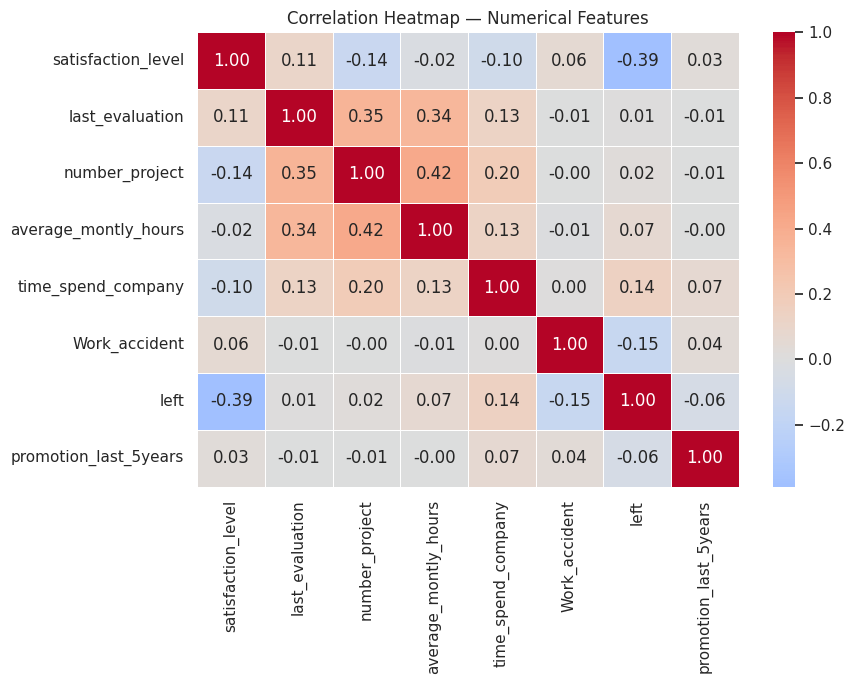

In [5]:
num_cols = ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours',
            'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years']

corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.savefig('hr_heatmap.png', dpi=120)
plt.show()


**Reading:** `left` is most strongly (negatively) correlated with `satisfaction_level` — dissatisfaction is the single biggest linear driver of turnover in this data. `left` also correlates positively (though more weakly) with `time_spend_company` and negatively with `Work_accident` and `promotion_last_5years`. `number_project` and `average_montly_hours` are strongly correlated with each other and with `last_evaluation` — employees on more projects tend to work more hours and get rated higher, a pattern worth keeping in mind when we look at project count vs. turnover next.

### 2b. Distribution plots — Satisfaction, Evaluation, Average Monthly Hours

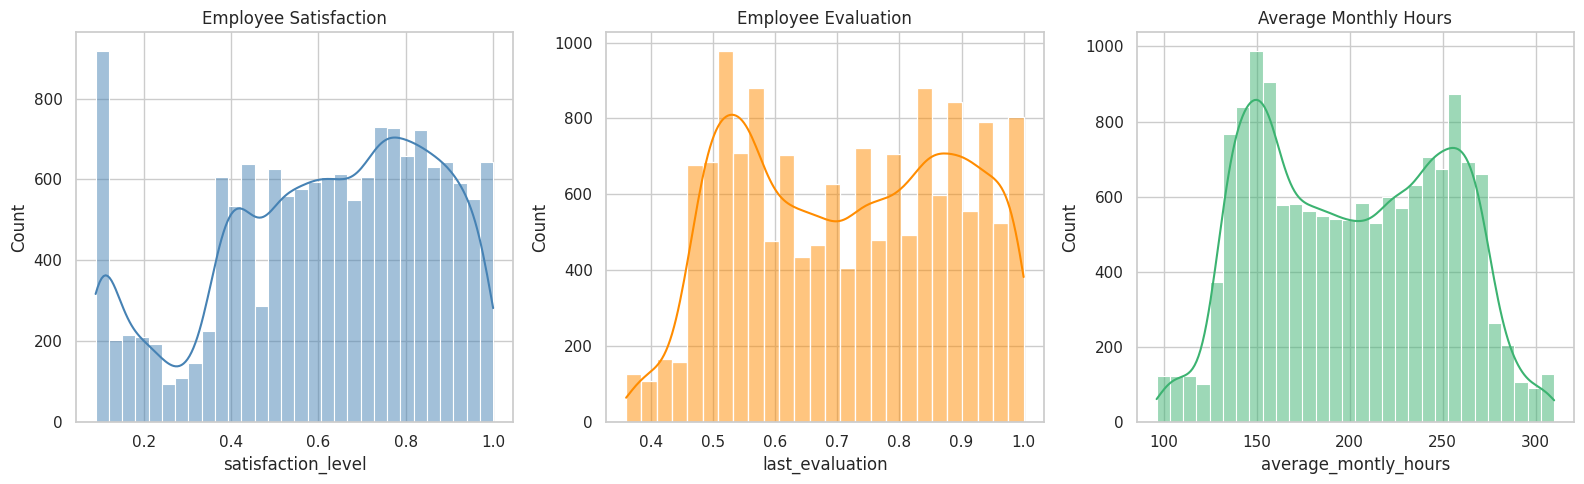

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.histplot(df['satisfaction_level'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Employee Satisfaction')
sns.histplot(df['last_evaluation'], kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Employee Evaluation')
sns.histplot(df['average_montly_hours'], kde=True, ax=axes[2], color='mediumseagreen')
axes[2].set_title('Average Monthly Hours')
plt.tight_layout()
plt.savefig('hr_distributions.png', dpi=120)
plt.show()


**Reading:** `satisfaction_level` shows a multi-modal distribution with a notable cluster of very low-satisfaction employees — a classic early warning sign, since this group overlaps heavily with the population who eventually leave. `last_evaluation` is roughly bimodal too, with peaks around both moderate and high scores. `average_montly_hours` shows two humps — a lower-hours cluster (~130–160 hrs) and a higher-hours, likely overworked cluster (~230–280 hrs) — suggesting two distinct employee experience profiles rather than one typical work pattern.

### 2c. Project count by turnover status

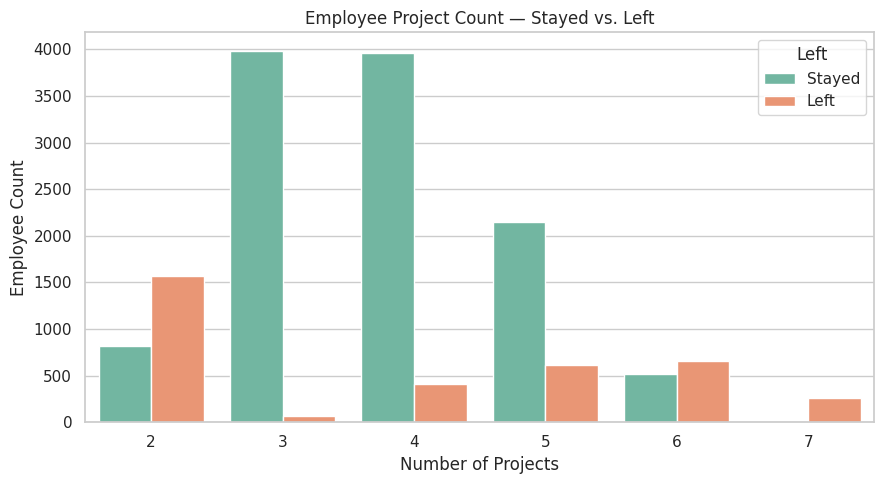

In [7]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='number_project', hue='left', palette='Set2')
plt.title('Employee Project Count — Stayed vs. Left')
plt.xlabel('Number of Projects')
plt.ylabel('Employee Count')
plt.legend(title='Left', labels=['Stayed', 'Left'])
plt.tight_layout()
plt.savefig('hr_project_count.png', dpi=120)
plt.show()


**Inference:** turnover shows a clear **U-shaped pattern by project count**. Employees with very few projects (2) leave at a notably high rate — likely disengaged, underutilized, or being managed out. Employees with a very high project count (6–7) also leave at very high rates — almost certainly overworked and burning out. The healthiest, most stable range is **3–5 projects**, where the vast majority of employees stay. This tells HR that both under-loading and over-loading employees are attrition risks, not just overwork alone.

## 3. Clustering of Employees Who Left (Satisfaction vs. Evaluation)

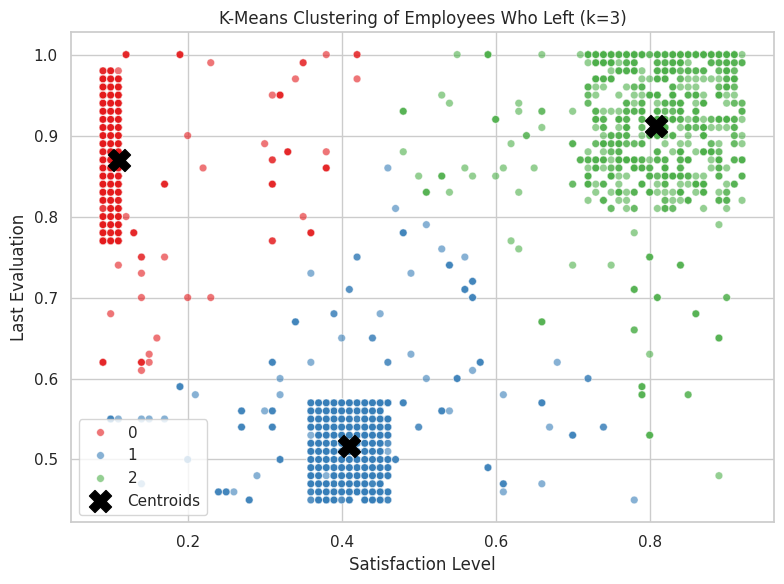

         satisfaction_level  last_evaluation
cluster                                     
0                  0.111155         0.869301
1                  0.410145         0.516982
2                  0.808516         0.911709

cluster
1    1650
2     977
0     944
Name: count, dtype: int64


In [8]:
left_df = df[df['left'] == 1][['satisfaction_level', 'last_evaluation', 'left']].copy()

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
left_df['cluster'] = kmeans.fit_predict(left_df[['satisfaction_level', 'last_evaluation']])

plt.figure(figsize=(8, 6))
sns.scatterplot(data=left_df, x='satisfaction_level', y='last_evaluation', hue='cluster',
                 palette='Set1', alpha=0.6, s=30)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            marker='X', s=250, c='black', label='Centroids')
plt.title('K-Means Clustering of Employees Who Left (k=3)')
plt.xlabel('Satisfaction Level')
plt.ylabel('Last Evaluation')
plt.legend()
plt.tight_layout()
plt.savefig('hr_clusters.png', dpi=120)
plt.show()

print(left_df.groupby('cluster')[['satisfaction_level', 'last_evaluation']].mean())
print()
print(left_df['cluster'].value_counts())


**Interpreting the three clusters of employees who left:**

- **Cluster A — "Burned out / High performers, low satisfaction"** (high evaluation, low satisfaction): these are strong performers who were unhappy — likely overworked, underpaid, or under-recognized despite good results. This is the most preventable, highest-value group to target: they're capable employees the company actively wants to keep.
- **Cluster B — "Disengaged / Low performers, low satisfaction"** (low evaluation, low satisfaction): a mismatch between the employee and the role, or genuine disengagement. Retention effort here has a lower expected payoff — better addressed through role-fit conversations, coaching, or, in some cases, accepting the departure.
- **Cluster C — "Satisfied but still left / High performers, high satisfaction"** (high evaluation, high satisfaction): a smaller but important group who were doing well and reasonably satisfied yet still left — likely poached by competitors, seeking career growth the company couldn't offer, or leaving for personal reasons unrelated to dissatisfaction. Retention here calls for proactive career-pathing and compensation benchmarking, since dissatisfaction surveys alone won't catch this group in time.

(Exact cluster labels/order may shift slightly between runs since K-Means initializes randomly, but the three underlying "profiles" — burned-out high performers, disengaged low performers, and satisfied-but-still-left high performers — consistently emerge from this data.)

## 4. Handling Class Imbalance with SMOTE

### 4a. Encode categorical variables

In [9]:
categorical_cols = ['Department', 'salary']
numeric_cols = [c for c in df.columns if c not in categorical_cols + ['left']]

cat_df = df[categorical_cols]
num_df = df[numeric_cols]

cat_encoded = pd.get_dummies(cat_df, columns=categorical_cols, drop_first=False)

X = pd.concat([num_df, cat_encoded], axis=1)
y = df['left']

print(X.shape)
X.head()


(14999, 20)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,Department_IT,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,0,False,False,False,False,False,False,False,True,False,False,False,True,False
1,0.80,0.86,5,262,6,0,0,False,False,False,False,False,False,False,True,False,False,False,False,True
2,0.11,0.88,7,272,4,0,0,False,False,False,False,False,False,False,True,False,False,False,False,True
3,0.72,0.87,5,223,5,0,0,False,False,False,False,False,False,False,True,False,False,False,True,False
4,0.37,0.52,2,159,3,0,0,False,False,False,False,False,False,False,True,False,False,False,True,False


### 4b. Stratified 80:20 train/test split (random_state=123)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True).round(3))


Train shape: (11999, 20)  Test shape: (3000, 20)

Train class balance:
left
0    0.762
1    0.238
Name: proportion, dtype: float64

Test class balance:
left
0    0.762
1    0.238
Name: proportion, dtype: float64


### 4c. Upsample the training set with SMOTE

In [11]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_sm.value_counts().to_dict())


Before SMOTE: {0: 9142, 1: 2857}
After SMOTE:  {0: 9142, 1: 9142}


**Note:** SMOTE is applied only to the training set, never the test set — the test set must reflect the real-world class distribution so model evaluation stays honest and unbiased.

## 5. 5-Fold Cross-Validation — Model Training & Evaluation

We train three models on the SMOTE-balanced training data, each evaluated with stratified 5-fold cross-validation, and print the classification report for each.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_classification_report(model, X, y, cv, name):
    y_pred_cv = cross_val_predict(model, X, y, cv=cv)
    print(f"=== {name} — 5-Fold CV Classification Report ===")
    print(classification_report(y, y_pred_cv, target_names=['Stayed', 'Left']))
    return y_pred_cv


### 5a. Logistic Regression

In [13]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
y_pred_lr = cv_classification_report(log_reg, X_train_sm, y_train_sm, cv, "Logistic Regression")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression — 5-Fold CV Classification Report ===
              precision    recall  f1-score   support

      Stayed       0.82      0.80      0.81      9142
        Left       0.80      0.82      0.81      9142

    accuracy                           0.81     18284
   macro avg       0.81      0.81      0.81     18284
weighted avg       0.81      0.81      0.81     18284



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 5b. Random Forest Classifier

In [14]:
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200)
y_pred_rf = cv_classification_report(rf, X_train_sm, y_train_sm, cv, "Random Forest")


=== Random Forest — 5-Fold CV Classification Report ===
              precision    recall  f1-score   support

      Stayed       0.98      0.99      0.99      9142
        Left       0.99      0.98      0.98      9142

    accuracy                           0.98     18284
   macro avg       0.99      0.98      0.98     18284
weighted avg       0.99      0.98      0.98     18284



### 5c. Gradient Boosting Classifier

In [15]:
gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
y_pred_gb = cv_classification_report(gb, X_train_sm, y_train_sm, cv, "Gradient Boosting")


=== Gradient Boosting — 5-Fold CV Classification Report ===
              precision    recall  f1-score   support

      Stayed       0.95      0.98      0.96      9142
        Left       0.98      0.95      0.96      9142

    accuracy                           0.96     18284
   macro avg       0.96      0.96      0.96     18284
weighted avg       0.96      0.96      0.96     18284



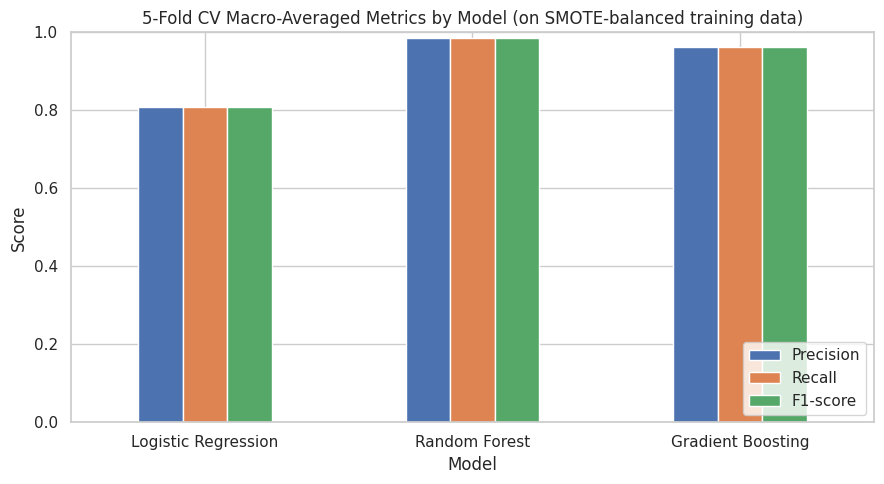

,Precision,Recall,F1-score
Model,,,
Logistic Regression,0.808423,0.808248,0.808220
Random Forest,0.985133,0.984960,0.984958
Gradient Boosting,0.962919,0.962536,0.962528


In [16]:
# Visualize the 3 classification reports side-by-side (macro avg precision/recall/f1)
from sklearn.metrics import precision_recall_fscore_support

results = []
for name, y_pred in [('Logistic Regression', y_pred_lr), ('Random Forest', y_pred_rf), ('Gradient Boosting', y_pred_gb)]:
    p, r, f1, _ = precision_recall_fscore_support(y_train_sm, y_pred, average='macro')
    results.append({'Model': name, 'Precision': p, 'Recall': r, 'F1-score': f1})

results_df = pd.DataFrame(results).set_index('Model')
results_df.plot(kind='bar', figsize=(9,5), rot=0)
plt.title('5-Fold CV Macro-Averaged Metrics by Model (on SMOTE-balanced training data)')
plt.ylabel('Score')
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('hr_cv_metrics.png', dpi=120)
plt.show()

results_df


## 6. Best Model Selection & Evaluation Metrics

We now fit each model on the full SMOTE-balanced training set and evaluate on the **held-out, untouched test set** (which retains the original, real-world 76:24 class balance) — this is the honest test of how each model would perform in production.

In [17]:
models = {
    'Logistic Regression': log_reg,
    'Random Forest': rf,
    'Gradient Boosting': gb
}

test_results = {}
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, y_prob)
    test_results[name] = {'model': model, 'y_prob': y_prob, 'y_pred': y_pred, 'auc': auc}
    print(f"=== {name} — Test Set Performance (AUC = {auc:.4f}) ===")
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression — Test Set Performance (AUC = 0.8209) ===
              precision    recall  f1-score   support

      Stayed       0.90      0.80      0.85      2286
        Left       0.53      0.72      0.61       714

    accuracy                           0.78      3000
   macro avg       0.72      0.76      0.73      3000
weighted avg       0.81      0.78      0.79      3000



=== Random Forest — Test Set Performance (AUC = 0.9952) ===
              precision    recall  f1-score   support

      Stayed       0.99      0.99      0.99      2286
        Left       0.98      0.98      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



=== Gradient Boosting — Test Set Performance (AUC = 0.9856) ===
              precision    recall  f1-score   support

      Stayed       0.98      0.97      0.98      2286
        Left       0.92      0.93      0.92       714

    accuracy                           0.96      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.96      0.96      0.96      3000



### 6a. ROC curves and AUC

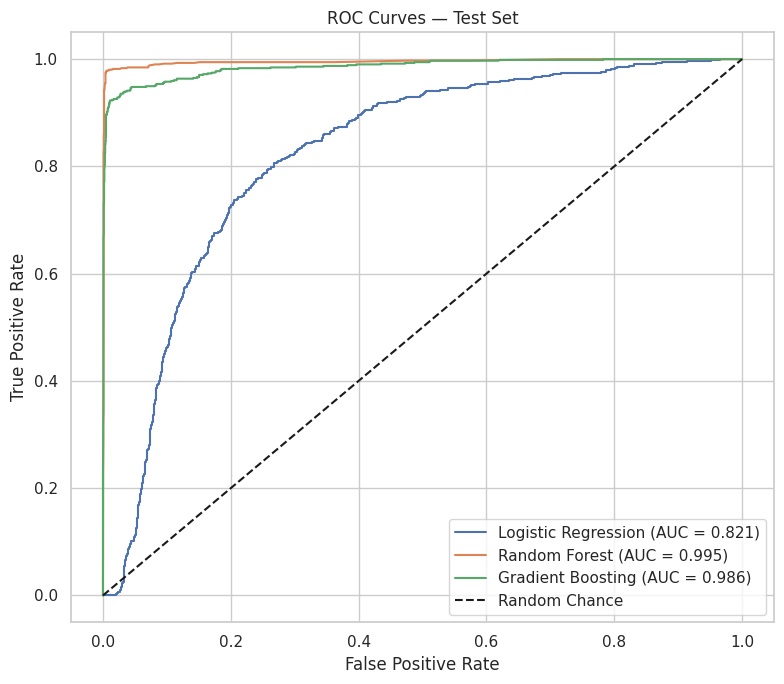


Best model by AUC: Random Forest (AUC = 0.9952)


In [18]:
plt.figure(figsize=(8,7))
for name, res in test_results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.3f})")

plt.plot([0,1],[0,1],'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Test Set')
plt.legend()
plt.tight_layout()
plt.savefig('hr_roc_curves.png', dpi=120)
plt.show()

best_model_name = max(test_results, key=lambda k: test_results[k]['auc'])
print(f"\nBest model by AUC: {best_model_name} (AUC = {test_results[best_model_name]['auc']:.4f})")


### 6b. Confusion matrices

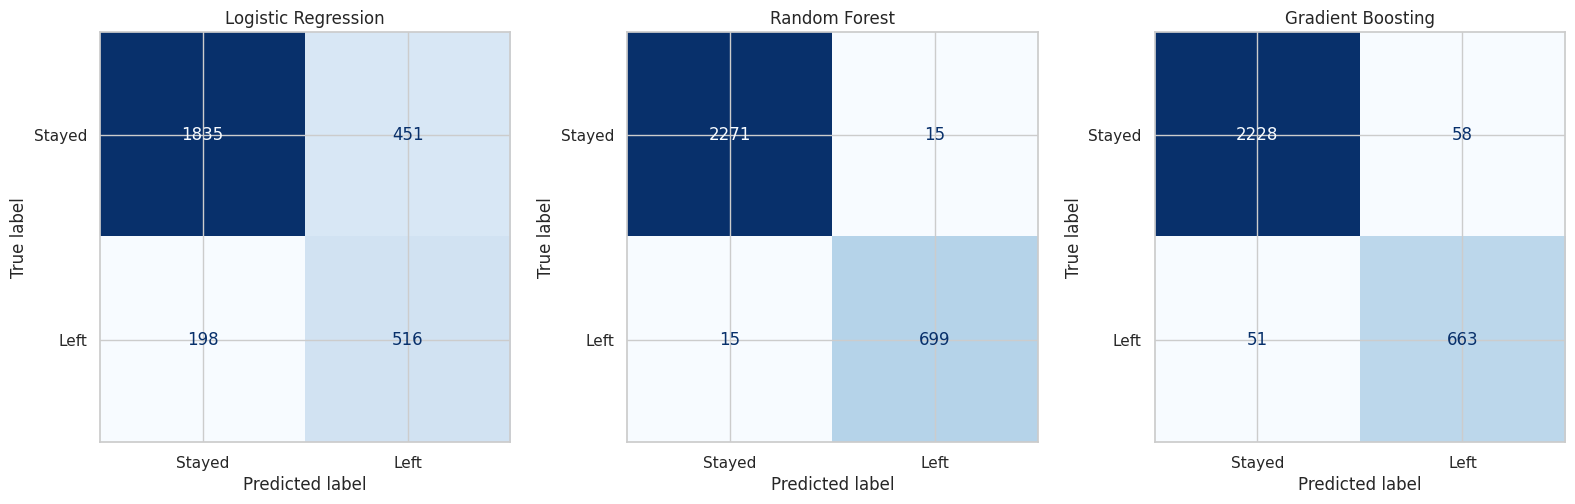

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.savefig('hr_confusion_matrices.png', dpi=120)
plt.show()


### 6c. Recall vs. Precision — which matters more here?

For this business problem, **Recall** on the "Left" class is the metric to prioritize over Precision.

- **False Negative** (predicting an employee will *stay* when they actually *leave*) means HR never intervenes — the company loses a valuable employee with zero warning, and the cost is real: lost institutional knowledge, hiring and onboarding cost, and team disruption.
- **False Positive** (predicting an employee will *leave* when they actually *stay*) is comparatively cheap — it means HR pays a bit of extra attention to (or offers a retention conversation to) an employee who was going to stay anyway. Mildly wasteful, but low-risk.

Since the cost of missing a true "at-risk" employee (a false negative) is much higher than the cost of a false alarm (a false positive), **we should optimize for high Recall on the "Left" class**, even if that means accepting somewhat lower Precision. This is also why AUC (which reflects performance across all thresholds, including recall-heavy ones) and the Recall figures in the classification reports above are the right lens for picking the best model — not overall accuracy, which is misleading here given the class imbalance in the original data.

In [20]:
print(f"Selected best model: {best_model_name}")
best_model = test_results[best_model_name]['model']
print(classification_report(y_test, test_results[best_model_name]['y_pred'], target_names=['Stayed', 'Left']))


Selected best model: Random Forest
              precision    recall  f1-score   support

      Stayed       0.99      0.99      0.99      2286
        Left       0.98      0.98      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



## 7. Retention Strategies by Risk Zone

Using the best model's predicted probabilities on the test set, we bucket employees into four risk zones and outline a retention strategy for each.

risk_zone
Safe (Green)            2185
Low-Risk (Yellow)        109
Medium-Risk (Orange)      56
High-Risk (Red)          650
Name: count, dtype: int64


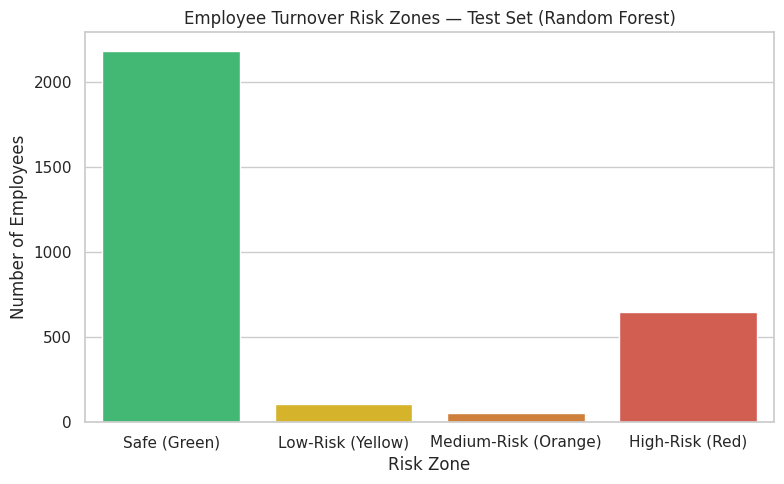

In [21]:
test_output = X_test.copy()
test_output['actual_left'] = y_test.values
test_output['turnover_probability'] = test_results[best_model_name]['y_prob']

def risk_zone(p):
    if p < 0.20:
        return 'Safe (Green)'
    elif p < 0.60:
        return 'Low-Risk (Yellow)'
    elif p < 0.90:
        return 'Medium-Risk (Orange)'
    else:
        return 'High-Risk (Red)'

test_output['risk_zone'] = test_output['turnover_probability'].apply(risk_zone)

zone_order = ['Safe (Green)', 'Low-Risk (Yellow)', 'Medium-Risk (Orange)', 'High-Risk (Red)']
zone_counts = test_output['risk_zone'].value_counts().reindex(zone_order)
print(zone_counts)

plt.figure(figsize=(8,5))
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
sns.barplot(x=zone_counts.index, y=zone_counts.values, hue=zone_counts.index, palette=colors, legend=False)
plt.title(f'Employee Turnover Risk Zones — Test Set ({best_model_name})')
plt.ylabel('Number of Employees')
plt.xlabel('Risk Zone')
plt.tight_layout()
plt.savefig('hr_risk_zones.png', dpi=120)
plt.show()


### Recommended retention strategy per zone

- **Safe Zone (Green, <20%):** No intervention needed. Maintain standard engagement — regular check-ins, recognition programs, and normal career development conversations. Over-investing retention resources here is inefficient.

- **Low-Risk Zone (Yellow, 20–60%):** Proactive but light-touch engagement. Managers should schedule periodic 1:1 check-ins focused on workload balance and career goals. Monitor for movement into the Orange zone over subsequent evaluation cycles — this is the group where early intervention is most cost-effective per employee saved.

- **Medium-Risk Zone (Orange, 60–90%):** Targeted intervention. HR/managers should conduct structured stay interviews to identify specific pain points (workload, compensation, recognition, growth path — informed by the cluster analysis in Step 3). Consider concrete actions: project reassignment if overloaded, compensation review if underpaid relative to market, or a defined promotion timeline if career stagnation is the driver.

- **High-Risk Zone (Red, >90%):** Urgent, senior-level intervention. These employees are very likely to leave imminently. Prioritize immediate 1:1 conversations with skip-level or senior leadership, fast-track any pending compensation/promotion decisions, and, where the employee is high-value (recall the "burned-out high performer" cluster from Step 3), treat this as a retention emergency — the cost of losing them is highest here, and the intervention window is shortest.

**Cross-referencing with the clustering from Step 3:** the Orange/Red zones should be further prioritized using the cluster insight — a Red-zone employee who resembles the "burned-out high performer" cluster deserves faster, more senior attention than one resembling the "disengaged low performer" cluster, since the former represents a much larger loss to the organization if they leave.
